# IMPROVE Smoke Event QC

This notebook validates IMPROVE high-absorption samples as smoke/event analogs for the Addis/ETAD HIPS offset question.

Primary questions:

- How much of the IMPROVE network overlaps the Addis/ETAD EC-loading and fAbs regime?
- Which high-fAbs rows are smoke-like candidates versus RT saturation or optical-regime artifacts?
- Does IMPROVE support high EC surface loading as a general explanation for the Addis HIPS offset?

Outputs are written under `research/improve_hips_offset/output/improve_smoke_event_qc/`. Plot cells also call `plt.show()`, so figures render inline when the notebook is run.

## 1. Setup

The setup follows the repository guidance in `AGENTS.md`: use the Anaconda Python environment, import the shared SPARTAN plotting package, keep generated output under this notebook's output folder, and avoid destructive filtering. QC flags below are non-destructive columns on the joined IMPROVE table.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/Users/ahmadjalil/github/aethmodular")
SPARTAN_DIR = PROJECT_DIR / "research" / "ftir_hips_chem"
THIS_DIR = PROJECT_DIR / "research" / "improve_hips_offset"
OUT_DIR = THIS_DIR / "output" / "improve_smoke_event_qc"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_IMPROVE_DIR = Path(
    "/Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/"
    "University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve"
)
IMPROVE_DIR = Path(os.environ.get("AETHMODULAR_IMPROVE_DIR", DEFAULT_IMPROVE_DIR)).expanduser().resolve()

SCRIPTS_DIR = SPARTAN_DIR / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from config import SITES, MAC_VALUE
from plotting import PlotConfig, apply_default_style

apply_default_style()
PlotConfig.set(sites="all", layout="individual", show_stats=True, show_1to1=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

NA_VALUES = [-999, "-999", -999.0, "-999.0"]
KEY_COLS = ["Dataset", "SiteCode", "POC", "Date", "AuxID"]
PRIMARY_IMPROVE_AREA_CM2 = 3.5
TRANS_SATURATION_RATIO = 0.01
REF_SATURATION_RATIO = 0.01
OC_EC_SMOKE_MIN = 5.0
RANDOM_SEED = 42

print(f"Project: {PROJECT_DIR}")
print(f"IMPROVE input folder: {IMPROVE_DIR}")
print(f"Output folder: {OUT_DIR}")
print(f"Reference MAC value from shared config: {MAC_VALUE}")

Project: /Users/ahmadjalil/github/aethmodular
IMPROVE input folder: /Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve
Output folder: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc
Reference MAC value from shared config: 10


## 2. Data Inventory

Read both IMPROVE workbooks, inspect parameter metadata, count rows/sites/date ranges, quantify missingness, and report duplicate standard keys before deduplication.

In [2]:
def find_excel_with_columns(directory, required_cols):
    required_cols = set(required_cols)
    for path in sorted(directory.glob("*.xlsx")):
        try:
            xl = pd.ExcelFile(path)
            if "Data" not in xl.sheet_names:
                continue
            cols = pd.read_excel(xl, sheet_name="Data", nrows=0).columns.astype(str).str.strip().tolist()
            if required_cols.issubset(cols):
                return path
        except Exception:
            continue
    raise FileNotFoundError(f"No Excel workbook in {directory} contains {sorted(required_cols)}")


def standardize_improve_frame(df):
    out = df.copy()
    out.columns = out.columns.astype(str).str.strip()
    if "Date" in out.columns:
        out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
    for col in out.columns:
        if col.endswith("_Val") or col in {"POC", "AuxID"}:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def duplicate_summary(df, key_cols=KEY_COLS):
    available = [c for c in key_cols if c in df.columns]
    if len(available) != len(key_cols):
        return {"duplicate_rows": np.nan, "duplicate_key_groups": np.nan}
    dup_mask = df.duplicated(key_cols, keep=False)
    return {
        "duplicate_rows": int(dup_mask.sum()),
        "duplicate_key_groups": int(df.loc[dup_mask, key_cols].drop_duplicates().shape[0]),
    }


def inventory_row(label, df):
    dup = duplicate_summary(df)
    date_min = df["Date"].min() if "Date" in df else pd.NaT
    date_max = df["Date"].max() if "Date" in df else pd.NaT
    return {
        "table": label,
        "rows": len(df),
        "columns": df.shape[1],
        "sites": df["SiteCode"].nunique() if "SiteCode" in df else np.nan,
        "date_min": date_min,
        "date_max": date_max,
        **dup,
    }


def value_missingness(df, label):
    value_cols = [c for c in df.columns if c.endswith("_Val")]
    if not value_cols:
        return pd.DataFrame()
    return (
        df[value_cols]
        .isna()
        .mean()
        .mul(100)
        .rename("missing_pct")
        .reset_index()
        .rename(columns={"index": "column"})
        .assign(table=label)
        .loc[:, ["table", "column", "missing_pct"]]
        .sort_values(["table", "missing_pct"], ascending=[True, False])
    )


chem_path = find_excel_with_columns(IMPROVE_DIR, ["SiteCode", "Date", "ECf_Val", "fAbs_Val"])
rt_path = find_excel_with_columns(IMPROVE_DIR, ["SiteCode", "Date", "RefF_635_Val", "TransF_635_Val"])

print(f"Chemistry workbook: {chem_path.name}")
print(f"RT workbook: {rt_path.name}")

chem_params = pd.read_excel(chem_path, sheet_name="Parameters", na_values=NA_VALUES)
rt_params = pd.read_excel(rt_path, sheet_name="Parameters", na_values=NA_VALUES)
sites = pd.read_excel(chem_path, sheet_name="Sites", na_values=NA_VALUES)

print("Chemistry parameters")
display(chem_params)
print("RT parameters")
display(rt_params)

chem = standardize_improve_frame(pd.read_excel(chem_path, sheet_name="Data", na_values=NA_VALUES))
rt = standardize_improve_frame(pd.read_excel(rt_path, sheet_name="Data", na_values=NA_VALUES))

inventory = pd.DataFrame([inventory_row("chemistry", chem), inventory_row("rt", rt)])
missingness = pd.concat(
    [value_missingness(chem, "chemistry"), value_missingness(rt, "rt")],
    ignore_index=True,
)

display(inventory)
display(missingness)

Chemistry workbook: ahzs645_20260422_122542_N0100.xlsx
RT workbook: ahzs645_20260422_122246_x0Ivu.xlsx
Chemistry parameters


,ParamID,ParamCode,ParamName,AQSCode,Units,Description
0,114,ECf,"Carbon, Elemental Total (Fine)",88321.0,ug/m^3,From TOR carbon fractions (E1+E2+E3-OP)
1,118,FEf,Iron (Fine),88126.0,ug/m^3,NaN
2,127,MF,"Mass, PM2.5 (Fine)",88101.0,ug/m^3,Gravimetric fine mass
3,141,OCf,"Carbon, Organic Total (Fine)",88320.0,ug/m^3,From TOR carbon fractions (OC1+OC2+OC3+OC4+OP)
4,301,fAbs,Filter Absorption Coefficient,63102.0,1/Mm,A calibrated absorption coefficient measured from a Teflon filter using a hybrid integrating plate and sphere method
5,911,SOILf,Soil (Fine),88348.0,ug/m^3,NaN
6,3694,FlowRate,Flow Rate,68101.0,R,The rate of air flow through an air sampling instrument
7,3695,SampDur,Sampling Duration,NaN,minutes,The duration of a given sampling period in minutes


RT parameters


,ParamID,ParamCode,ParamName,AQSCode,Units,Description
0,3719,RefF_635,Final laser reflectance at 635 nm,NaN,(ratio),Final laser reflectance at 635 nm
1,3726,RefI_635,Initial laser reflectance at 635 nm,NaN,(ratio),Initial laser reflectance at 635 nm
2,3733,TransF_635,Final laser transmittance at 635 nm,NaN,(ratio),Final laser transmittance at 635 nm
3,3740,TransI_635,Initial laser transmittance at 635 nm,NaN,(ratio),Initial laser transmittance at 635 nm
4,3747,RefM_635,Minimum laser reflectance at 635 nm,NaN,(ratio),Minimum laser reflectance at 635 nm
5,3754,TransM_635,Minimum laser transmittance at 635 nm,NaN,(ratio),Minimum laser transmittance at 635 nm


,table,rows,columns,sites,date_min,date_max,duplicate_rows,duplicate_key_groups
0,chemistry,626518,13,237,1988-03-02,2025-07-30,10,5
1,rt,185618,11,168,2016-01-01,2025-07-30,0,0


,table,column,missing_pct
0,chemistry,FlowRate_Val,69.452115
1,chemistry,SampDur_Val,69.452115
2,chemistry,fAbs_Val,34.221682
3,chemistry,ECf_Val,16.613250
4,chemistry,OCf_Val,16.613090
5,chemistry,MF_Val,15.292298
6,chemistry,SOILf_Val,14.997015
7,chemistry,FEf_Val,14.983608
8,rt,RefF_635_Val,7.867233
9,rt,TransF_635_Val,7.867233


,chemistry_rows,valid_ec_fabs_rows,rt_rows
year,,,
2011,23237,17823,0
2012,23318,18052,0
2013,22278,17358,0
2014,21907,17053,0
2015,21501,16877,0
2016,20508,15736,18213
2017,20622,16640,19524
2018,20361,16505,19351
2019,20842,16344,19632


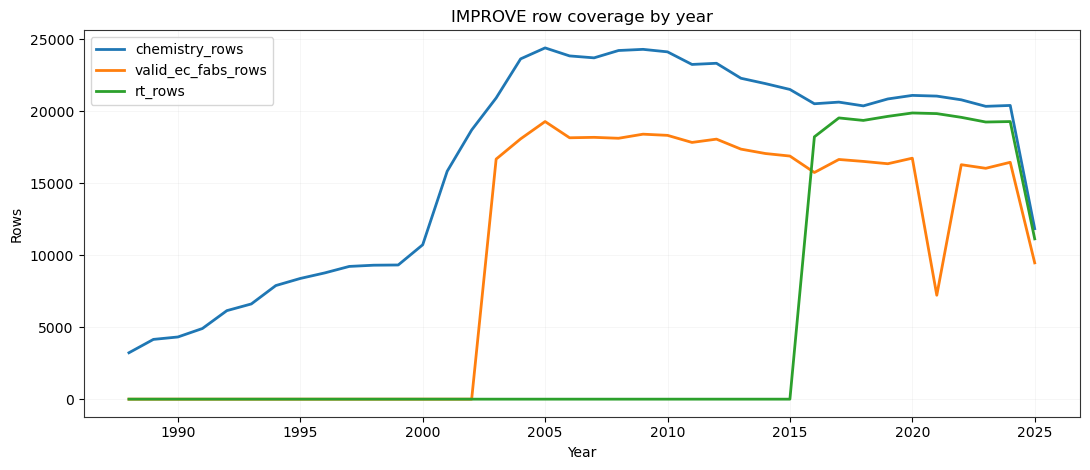

In [3]:
# Coverage by year for quick sanity checking.
chem_year = chem.assign(year=chem["Date"].dt.year)
rt_year = rt.assign(year=rt["Date"].dt.year)

coverage = pd.DataFrame({
    "chemistry_rows": chem_year.groupby("year").size(),
    "valid_ec_fabs_rows": chem_year.loc[
        (chem_year["ECf_Val"] > 0) & (chem_year["fAbs_Val"] > 0)
    ].groupby("year").size(),
    "rt_rows": rt_year.groupby("year").size(),
}).fillna(0).astype(int)

display(coverage.tail(15))

fig, ax = plt.subplots(figsize=(11, 4.8))
coverage[["chemistry_rows", "valid_ec_fabs_rows", "rt_rows"]].plot(ax=ax, lw=2)
ax.set_title("IMPROVE row coverage by year")
ax.set_xlabel("Year")
ax.set_ylabel("Rows")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "improve_data_coverage_by_year.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. Join Chemistry, RT, and Site Metadata

The join uses `Dataset`, `SiteCode`, `POC`, `Date`, and `AuxID`. Duplicate keys are reported above and then deduplicated with `keep='last'` before the one-to-one merge.

In [4]:
chem_dedup = chem.sort_values(KEY_COLS).drop_duplicates(KEY_COLS, keep="last")
rt_dedup = rt.sort_values(KEY_COLS).drop_duplicates(KEY_COLS, keep="last")

joined = chem_dedup.merge(
    rt_dedup,
    on=KEY_COLS,
    how="left",
    suffixes=("", "_rt"),
    validate="one_to_one",
)

site_keep = [
    c for c in [
        "Code", "Site", "Country", "State", "County", "Latitude", "Longitude",
        "Elevation", "Sponsor", "ProgramKey"
    ]
    if c in sites.columns
]
site_meta = (
    sites[site_keep]
    .drop_duplicates("Code")
    .rename(columns={"Code": "SiteCode", "Site": "SiteName"})
)
joined = joined.merge(site_meta, on="SiteCode", how="left")

raw_joined_csv = OUT_DIR / "improve_joined_chemistry_rt_raw.csv"
joined.to_csv(raw_joined_csv, index=False)
try:
    raw_joined_parquet = OUT_DIR / "improve_joined_chemistry_rt_raw.parquet"
    joined.to_parquet(raw_joined_parquet, index=False)
    cache_note = f"CSV and Parquet written: {raw_joined_csv.name}, {raw_joined_parquet.name}"
except Exception as exc:
    cache_note = f"CSV written: {raw_joined_csv.name}; Parquet skipped ({type(exc).__name__}: {exc})"

join_summary = pd.DataFrame([
    {"metric": "chemistry rows before dedupe", "value": len(chem)},
    {"metric": "chemistry rows after dedupe", "value": len(chem_dedup)},
    {"metric": "rt rows before dedupe", "value": len(rt)},
    {"metric": "rt rows after dedupe", "value": len(rt_dedup)},
    {"metric": "joined rows", "value": len(joined)},
    {"metric": "joined sites", "value": joined["SiteCode"].nunique()},
    {"metric": "rows with RT match", "value": joined["RefF_635_Val"].notna().sum()},
])
print(cache_note)
display(join_summary)
display(joined.head())

CSV and Parquet written: improve_joined_chemistry_rt_raw.csv, improve_joined_chemistry_rt_raw.parquet


,metric,value
0,chemistry rows before dedupe,626518
1,chemistry rows after dedupe,626513
2,rt rows before dedupe,185618
3,rt rows after dedupe,185618
4,joined rows,626513
5,joined sites,237
6,rows with RT match,171015


,Dataset,SiteCode,POC,Date,AuxID,ECf_Val,OCf_Val,fAbs_Val,FlowRate_Val,FEf_Val,MF_Val,SampDur_Val,SOILf_Val,RefF_635_Val,TransF_635_Val,RefI_635_Val,TransI_635_Val,RefM_635_Val,TransM_635_Val,SiteName,Country,State,County,Latitude,Longitude,Elevation,Sponsor,ProgramKey
0,IMPAER,ACAD1,1,1988-03-02,0,0.4814,1.2711,NaN,NaN,0.02651,NaN,NaN,0.29265,NaN,NaN,NaN,NaN,NaN,NaN,Acadia NP,US,ME,23009.0,44.3771,-68.261,157.0,NPS,IMPROVE
1,IMPAER,ACAD1,1,1988-03-05,0,0.3822,0.9966,NaN,NaN,0.02931,5.53333,NaN,0.29162,NaN,NaN,NaN,NaN,NaN,NaN,Acadia NP,US,ME,23009.0,44.3771,-68.261,157.0,NPS,IMPROVE
2,IMPAER,ACAD1,1,1988-03-09,0,0.2141,0.6389,NaN,NaN,0.01588,3.86139,NaN,0.20867,NaN,NaN,NaN,NaN,NaN,NaN,Acadia NP,US,ME,23009.0,44.3771,-68.261,157.0,NPS,IMPROVE
3,IMPAER,ACAD1,1,1988-03-12,0,0.1662,0.7276,NaN,NaN,0.02811,2.69103,NaN,0.33684,NaN,NaN,NaN,NaN,NaN,NaN,Acadia NP,US,ME,23009.0,44.3771,-68.261,157.0,NPS,IMPROVE
4,IMPAER,ACAD1,1,1988-03-16,0,0.1165,0.5343,NaN,NaN,0.02564,3.72881,NaN,0.34454,NaN,NaN,NaN,NaN,NaN,NaN,Acadia NP,US,ME,23009.0,44.3771,-68.261,157.0,NPS,IMPROVE


## 4. QC Flag Layer

These flags are non-destructive. They mark rows for later grouping without dropping anything from the joined table.

QC cache written: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_joined_qc.csv


,flag,true_rows,true_pct
0,valid_ec_fabs,379697,60.605
1,rt_available,171015,27.296
2,loading_available,174441,27.843
3,flow_duration_valid,184344,29.424
4,trans_zero_or_saturated,2292,0.366
5,ref_zero_or_saturated,3,0.000
6,rt_saturated,2294,0.366
7,extreme_mass,50015,7.983
8,extreme_oc_ec,20365,3.251
9,western_us,337295,53.837


,threshold,value
0,fAbs_p99,11.2200
1,fAbs_p995,14.5501
2,OCf_p95,2.8784
3,MF_p90,7.9125
4,MF_p95,10.3864
5,OC_EC_p90,12.5206
6,OC_EC_p95,17.0354
7,trans_od_proxy_p90,2.1540


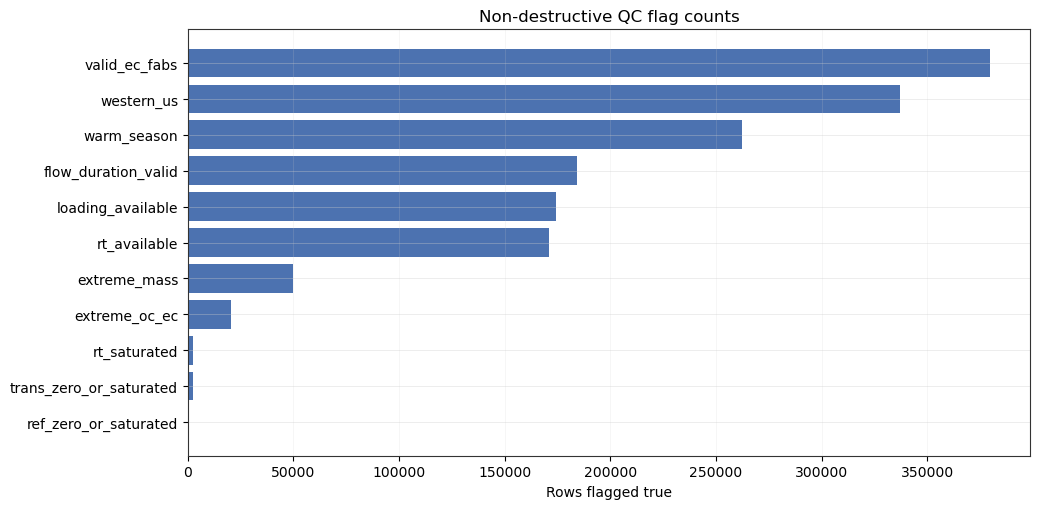

In [5]:
def ratio_safe(num, den):
    num = pd.to_numeric(num, errors="coerce")
    den = pd.to_numeric(den, errors="coerce")
    return pd.Series(
        np.where((den > 0) & np.isfinite(den) & np.isfinite(num), num / den, np.nan),
        index=num.index,
    )


qc_joined = joined.copy()

qc_joined["valid_ec_fabs"] = (
    qc_joined["ECf_Val"].notna()
    & qc_joined["fAbs_Val"].notna()
    & (qc_joined["ECf_Val"] > 0)
    & (qc_joined["fAbs_Val"] > 0)
)

qc_joined["flow_duration_valid"] = (
    qc_joined["FlowRate_Val"].notna()
    & qc_joined["SampDur_Val"].notna()
    & (qc_joined["FlowRate_Val"] > 0)
    & (qc_joined["SampDur_Val"] > 0)
)
qc_joined["volume_m3"] = np.where(
    qc_joined["flow_duration_valid"],
    qc_joined["FlowRate_Val"] * qc_joined["SampDur_Val"] / 1000.0,
    np.nan,
)
qc_joined["EC_loading_ug"] = qc_joined["ECf_Val"] * qc_joined["volume_m3"]
qc_joined["EC_loading_ug_cm2_area_3p5"] = qc_joined["EC_loading_ug"] / PRIMARY_IMPROVE_AREA_CM2
qc_joined["loading_available"] = qc_joined["EC_loading_ug_cm2_area_3p5"].notna()

qc_joined["fAbs_per_EC"] = ratio_safe(qc_joined["fAbs_Val"], qc_joined["ECf_Val"])
qc_joined["OC_EC"] = ratio_safe(qc_joined["OCf_Val"], qc_joined["ECf_Val"])
qc_joined["FE_EC"] = ratio_safe(qc_joined["FEf_Val"], qc_joined["ECf_Val"])
qc_joined["SOIL_EC"] = ratio_safe(qc_joined["SOILf_Val"], qc_joined["ECf_Val"])

rt_core = [
    "RefF_635_Val", "TransF_635_Val", "RefI_635_Val", "TransI_635_Val",
    "RefM_635_Val", "TransM_635_Val",
]
qc_joined["rt_available"] = qc_joined[rt_core].notna().all(axis=1)

qc_joined["trans_min_over_initial"] = ratio_safe(qc_joined["TransM_635_Val"], qc_joined["TransI_635_Val"])
qc_joined["trans_final_over_initial"] = ratio_safe(qc_joined["TransF_635_Val"], qc_joined["TransI_635_Val"])
qc_joined["ref_min_over_initial"] = ratio_safe(qc_joined["RefM_635_Val"], qc_joined["RefI_635_Val"])
qc_joined["ref_final_over_initial"] = ratio_safe(qc_joined["RefF_635_Val"], qc_joined["RefI_635_Val"])
qc_joined["rt_sum_min"] = qc_joined["TransM_635_Val"] + qc_joined["RefM_635_Val"]
qc_joined["rt_sum_initial"] = qc_joined["TransI_635_Val"] + qc_joined["RefI_635_Val"]
qc_joined["rt_sum_min_over_initial"] = ratio_safe(qc_joined["rt_sum_min"], qc_joined["rt_sum_initial"])
qc_joined["trans_od_proxy"] = -np.log(qc_joined["trans_min_over_initial"].clip(lower=1e-9))

qc_joined["trans_zero_or_saturated"] = (
    qc_joined["rt_available"]
    & (
        (qc_joined["TransM_635_Val"] <= 0)
        | (qc_joined["TransI_635_Val"] <= 0)
        | (qc_joined["trans_min_over_initial"] <= TRANS_SATURATION_RATIO)
    )
)
qc_joined["ref_zero_or_saturated"] = (
    qc_joined["rt_available"]
    & (
        (qc_joined["RefM_635_Val"] <= 0)
        | (qc_joined["RefI_635_Val"] <= 0)
        | (qc_joined["ref_min_over_initial"] <= REF_SATURATION_RATIO)
    )
)
qc_joined["rt_saturated"] = qc_joined["trans_zero_or_saturated"] | qc_joined["ref_zero_or_saturated"]

western_states = {"CA", "OR", "WA", "MT", "ID", "NV", "AZ", "NM", "CO", "UT", "WY"}
qc_joined["western_us"] = qc_joined["State"].isin(western_states)
qc_joined["warm_season"] = qc_joined["Date"].dt.month.between(6, 10)

qc = qc_joined[qc_joined["valid_ec_fabs"] & qc_joined["rt_available"] & qc_joined["loading_available"]].copy()
valid_positive = qc_joined[qc_joined["valid_ec_fabs"]].copy()

qc_thresholds = {
    "fAbs_p99": qc["fAbs_Val"].quantile(0.99),
    "fAbs_p995": qc["fAbs_Val"].quantile(0.995),
    "OCf_p95": qc["OCf_Val"].quantile(0.95),
    "MF_p90": qc["MF_Val"].quantile(0.90),
    "MF_p95": qc["MF_Val"].quantile(0.95),
    "OC_EC_p90": qc["OC_EC"].quantile(0.90),
    "OC_EC_p95": qc["OC_EC"].quantile(0.95),
    "trans_od_proxy_p90": qc["trans_od_proxy"].quantile(0.90),
}

qc_joined["extreme_mass"] = qc_joined["MF_Val"] >= qc_thresholds["MF_p95"]
qc_joined["extreme_oc_ec"] = qc_joined["OC_EC"] >= qc_thresholds["OC_EC_p95"]

qc = qc_joined[qc_joined["valid_ec_fabs"] & qc_joined["rt_available"] & qc_joined["loading_available"]].copy()
valid_positive = qc_joined[qc_joined["valid_ec_fabs"]].copy()

qc_csv = OUT_DIR / "improve_joined_qc.csv"
qc_joined.to_csv(qc_csv, index=False)

flag_cols = [
    "valid_ec_fabs", "rt_available", "loading_available", "flow_duration_valid",
    "trans_zero_or_saturated", "ref_zero_or_saturated", "rt_saturated",
    "extreme_mass", "extreme_oc_ec", "western_us", "warm_season",
]
flag_summary = pd.DataFrame([
    {"flag": c, "true_rows": int(qc_joined[c].sum()), "true_pct": qc_joined[c].mean() * 100}
    for c in flag_cols
])
threshold_table = pd.DataFrame([{"threshold": k, "value": v} for k, v in qc_thresholds.items()])

print(f"QC cache written: {qc_csv}")
display(flag_summary.round(3))
display(threshold_table.round(4))

fig, ax = plt.subplots(figsize=(10.5, 5.2))
plot_flags = flag_summary.sort_values("true_rows", ascending=True)
ax.barh(plot_flags["flag"], plot_flags["true_rows"], color="#4C72B0")
ax.set_title("Non-destructive QC flag counts")
ax.set_xlabel("Rows flagged true")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "improve_qc_flag_counts.png", dpi=220, bbox_inches="tight")
plt.show()

## 5. ETAD/Addis Comparability

Reuse the ETAD/Addis reference regime produced by the existing narrative notebook, then compare IMPROVE by EC concentration, EC surface loading, fAbs, OC/EC, and RT saturation flags.

In [6]:
PRIOR_OUT_DIR = THIS_DIR / "output" / "improve_hips_offset_narrative"
spartan_ref_path = PRIOR_OUT_DIR / "spartan_etad_reference.csv"
if not spartan_ref_path.exists():
    raise FileNotFoundError(
        f"Missing {spartan_ref_path}. Run improve_hips_offset_narrative.ipynb first, "
        "or copy the SPARTAN ETAD reference table into that output folder."
    )

spartan_ref = pd.read_csv(spartan_ref_path)
etad_ref = spartan_ref.loc[spartan_ref["SiteName"].eq("Addis_Ababa")].iloc[0]
ETAD_FABS_MIN = float(etad_ref["HIPS_Fabs_min"])
ETAD_FABS_MAX = float(etad_ref["HIPS_Fabs_max"])
ETAD_FABS_MEDIAN = float(etad_ref["HIPS_Fabs_median"])
ETAD_LOADING_P05 = float(etad_ref["EC_loading_ug_cm2_p05"])
ETAD_LOADING_MEDIAN = float(etad_ref["EC_loading_ug_cm2_median"])
ETAD_LOADING_P95 = float(etad_ref["EC_loading_ug_cm2_p95"])

qc_joined["etad_loading_p05p95"] = qc_joined["EC_loading_ug_cm2_area_3p5"].between(
    ETAD_LOADING_P05, ETAD_LOADING_P95, inclusive="both"
)
qc_joined["etad_loading_or_higher"] = qc_joined["EC_loading_ug_cm2_area_3p5"] >= ETAD_LOADING_P05
qc_joined["etad_fabs_range"] = qc_joined["fAbs_Val"].between(ETAD_FABS_MIN, ETAD_FABS_MAX, inclusive="both")
qc_joined["etad_loading_and_fabs"] = qc_joined["etad_loading_p05p95"] & qc_joined["etad_fabs_range"]

qc = qc_joined[qc_joined["valid_ec_fabs"] & qc_joined["rt_available"] & qc_joined["loading_available"]].copy()
valid_positive = qc_joined[qc_joined["valid_ec_fabs"]].copy()
loading_matched = qc[qc["etad_loading_p05p95"]].copy()
both_matched = qc[qc["etad_loading_and_fabs"]].copy()

compare_groups = {
    "valid positive EC/fAbs": valid_positive,
    "RT + loading available": qc,
    "ETAD loading p05-p95": loading_matched,
    "ETAD fAbs + loading": both_matched,
    "ETAD loading or higher": qc[qc["etad_loading_or_higher"]],
    "RT saturated": qc[qc["rt_saturated"]],
}

compare_rows = []
for name, g in compare_groups.items():
    compare_rows.append({
        "group": name,
        "n": len(g),
        "sites": g["SiteCode"].nunique() if len(g) else 0,
        "EC_median": g["ECf_Val"].median() if len(g) else np.nan,
        "fAbs_median": g["fAbs_Val"].median() if len(g) else np.nan,
        "EC_loading_median": g["EC_loading_ug_cm2_area_3p5"].median() if len(g) else np.nan,
        "OC_EC_median": g["OC_EC"].median() if len(g) else np.nan,
        "rt_saturated_pct": g["rt_saturated"].mean() * 100 if len(g) else np.nan,
    })
comparability_summary = pd.DataFrame(compare_rows)
comparability_summary.to_csv(OUT_DIR / "improve_etad_comparability_summary.csv", index=False)

display(spartan_ref)
display(comparability_summary.round(3))

,SiteName,n_filtered,HIPS_Fabs_median,HIPS_Fabs_min,HIPS_Fabs_max,EC_ftir_median,EC_loading_ug_cm2_p05,EC_loading_ug_cm2_median,EC_loading_ug_cm2_p95,T1_over_blank_median,pct_T1_lt_50pct_blank,pct_tau_gt_1
0,Beijing,144,12.960956,3.750007,37.917433,1.294262,1.128138,2.566540,6.902855,0.740888,1.554404,0.000000
1,Delhi,57,39.900288,1.558061,96.309654,3.502128,1.264310,5.134007,14.052849,0.642098,20.000000,10.476190
2,JPL,60,5.741870,2.266428,10.394390,0.612894,1.021301,1.231623,1.766694,0.870004,0.000000,0.000000
3,Addis_Ababa,190,47.132129,28.085699,85.852735,4.624584,4.725187,9.491196,19.640041,0.416010,83.673469,42.857143


,group,n,sites,EC_median,fAbs_median,EC_loading_median,OC_EC_median,rt_saturated_pct
0,valid positive EC/fAbs,379697,214,0.121,1.51,0.923,5.372,0.433
1,RT + loading available,145200,167,0.106,1.30,0.920,5.639,1.112
2,ETAD loading p05-p95,6946,158,0.780,7.10,6.747,3.864,12.093
3,ETAD fAbs + loading,24,14,2.040,33.02,16.258,5.963,25.000
4,ETAD loading or higher,7366,158,0.806,7.34,6.976,3.834,12.870
5,RT saturated,1615,139,0.620,5.16,5.397,6.478,100.000


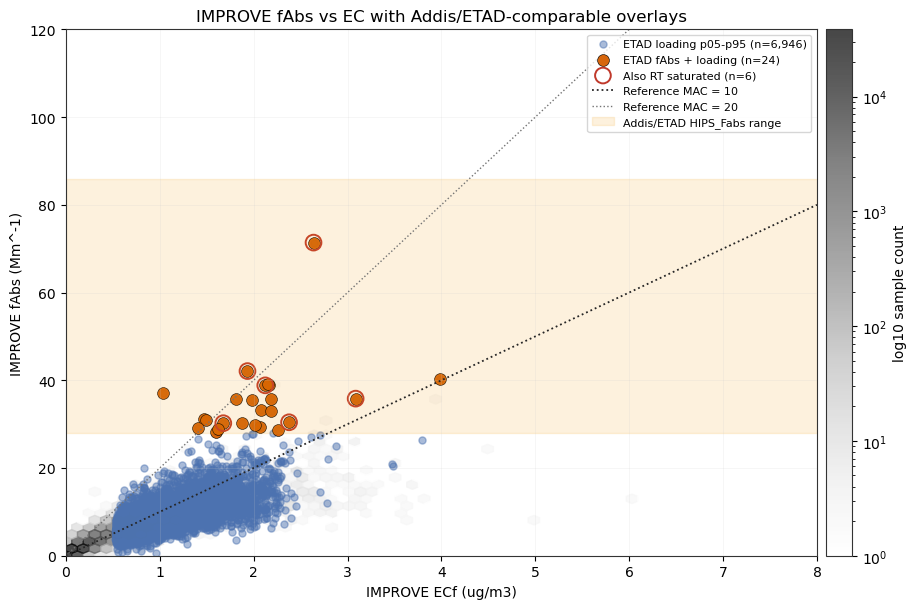

In [7]:
fig, ax = plt.subplots(figsize=(9.8, 6.2))
base = qc[(qc["ECf_Val"] <= 8) & (qc["fAbs_Val"] <= 120)].copy()
hb = ax.hexbin(
    base["ECf_Val"],
    base["fAbs_Val"],
    gridsize=65,
    extent=(0, 8, 0, 120),
    mincnt=1,
    bins="log",
    cmap="Greys",
    alpha=0.72,
)
fig.colorbar(hb, ax=ax, pad=0.01, label="log10 sample count")

ax.scatter(
    loading_matched["ECf_Val"],
    loading_matched["fAbs_Val"],
    s=26,
    color="#4C72B0",
    alpha=0.48,
    label=f"ETAD loading p05-p95 (n={len(loading_matched):,})",
)
ax.scatter(
    both_matched["ECf_Val"],
    both_matched["fAbs_Val"],
    s=72,
    color="#D55E00",
    edgecolor="black",
    linewidth=0.45,
    alpha=0.95,
    label=f"ETAD fAbs + loading (n={len(both_matched):,})",
)
saturated_both = both_matched[both_matched["rt_saturated"]]
if len(saturated_both):
    ax.scatter(
        saturated_both["ECf_Val"],
        saturated_both["fAbs_Val"],
        s=128,
        facecolor="none",
        edgecolor="#C0392B",
        linewidth=1.4,
        label=f"Also RT saturated (n={len(saturated_both):,})",
    )

x_line = np.linspace(0, 8, 200)
ax.plot(x_line, MAC_VALUE * x_line, color="0.15", lw=1.3, ls=":", label=f"Reference MAC = {MAC_VALUE:g}")
ax.plot(x_line, 20 * x_line, color="0.45", lw=1.0, ls=":", label="Reference MAC = 20")
ax.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color="#F39C12", alpha=0.14, label="Addis/ETAD HIPS_Fabs range")
ax.set_xlim(0, 8)
ax.set_ylim(0, 120)
ax.set_xlabel("IMPROVE ECf (ug/m3)")
ax.set_ylabel("IMPROVE fAbs (Mm^-1)")
ax.set_title("IMPROVE fAbs vs EC with Addis/ETAD-comparable overlays")
ax.legend(loc="upper right", fontsize=8, frameon=True)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "improve_etad_comparable_fabs_vs_ec.png", dpi=240, bbox_inches="tight")
plt.show()

## 6. Smoke/Event Candidate Screen

The score intentionally carries forward the existing narrative definitions so candidate counts remain comparable:

- `fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5`
- `smoke_like_score >= 8`
- `smoke_like_score >= 9`

Western and warm-season context is retained as descriptive context rather than baked into the legacy score.

In [8]:
char = qc.copy()
char["year_month"] = char["Date"].dt.to_period("M").astype(str)
char["month"] = char["Date"].dt.month

char["char_high_loading"] = char["EC_loading_ug_cm2_area_3p5"] >= ETAD_LOADING_P05
char["char_high_fAbs_p99"] = char["fAbs_Val"] >= qc_thresholds["fAbs_p99"]
char["char_very_high_fAbs_p995"] = char["fAbs_Val"] >= qc_thresholds["fAbs_p995"]
char["char_high_OC"] = char["OCf_Val"] >= qc_thresholds["OCf_p95"]
char["char_organic_rich"] = char["OC_EC"] >= OC_EC_SMOKE_MIN
char["char_extreme_OC_EC"] = char["OC_EC"] >= qc_thresholds["OC_EC_p90"]
char["char_high_MF"] = char["MF_Val"] >= qc_thresholds["MF_p90"]
char["char_rt_optical_loading"] = char["trans_od_proxy"] >= qc_thresholds["trans_od_proxy_p90"]

char["smoke_like_score"] = (
    2 * char["char_high_fAbs_p99"].astype(int)
    + 1 * char["char_very_high_fAbs_p995"].astype(int)
    + 2 * char["char_high_OC"].astype(int)
    + 1 * char["char_organic_rich"].astype(int)
    + 1 * char["char_extreme_OC_EC"].astype(int)
    + 1 * char["char_high_MF"].astype(int)
    + 1 * char["char_high_loading"].astype(int)
    + 1 * char["char_rt_optical_loading"].astype(int)
)

char["context_western_warm"] = char["western_us"] & char["warm_season"]
char["event_context"] = np.select(
    [
        char["western_us"] & char["warm_season"],
        char["western_us"],
        char["warm_season"],
    ],
    ["western warm-season", "western other-season", "nonwestern warm-season"],
    default="nonwestern other-season",
)

p99_loading_ocec = char[char["char_high_fAbs_p99"] & char["char_high_loading"] & char["char_organic_rich"]].copy()
score_ge8 = char[char["smoke_like_score"] >= 8].copy()
score_ge9 = char[char["smoke_like_score"] >= 9].copy()

candidate_groups = {
    "QC all RT + loading": char,
    "fAbs >= QC p99": char[char["char_high_fAbs_p99"]],
    "fAbs >= QC p99 + ETAD-low loading": char[char["char_high_fAbs_p99"] & char["char_high_loading"]],
    "fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5": p99_loading_ocec,
    "fAbs >= QC p99.5 + ETAD-low loading + OC/EC >= 5": char[
        char["char_very_high_fAbs_p995"] & char["char_high_loading"] & char["char_organic_rich"]
    ],
    "smoke_like_score >= 8": score_ge8,
    "smoke_like_score >= 9": score_ge9,
}

candidate_rows = []
for name, g in candidate_groups.items():
    candidate_rows.append({
        "group": name,
        "n": len(g),
        "sites": g["SiteCode"].nunique() if len(g) else 0,
        "western_us_pct": g["western_us"].mean() * 100 if len(g) else np.nan,
        "warm_season_pct": g["warm_season"].mean() * 100 if len(g) else np.nan,
        "rt_saturated_pct": g["rt_saturated"].mean() * 100 if len(g) else np.nan,
        "fAbs_median": g["fAbs_Val"].median() if len(g) else np.nan,
        "EC_loading_median": g["EC_loading_ug_cm2_area_3p5"].median() if len(g) else np.nan,
        "OC_EC_median": g["OC_EC"].median() if len(g) else np.nan,
        "MF_median": g["MF_Val"].median() if len(g) else np.nan,
    })
candidate_summary = pd.DataFrame(candidate_rows)
candidate_summary.to_csv(OUT_DIR / "improve_smoke_event_candidate_summary.csv", index=False)

candidate_cols = [c for c in [
    "SiteCode", "SiteName", "State", "Date", "POC", "AuxID",
    "ECf_Val", "OCf_Val", "fAbs_Val", "EC_loading_ug_cm2_area_3p5",
    "OC_EC", "MF_Val", "trans_min_over_initial", "trans_od_proxy",
    "rt_saturated", "western_us", "warm_season", "event_context", "smoke_like_score",
] if c in score_ge8.columns]
smoke_event_candidates = score_ge8.sort_values(
    ["smoke_like_score", "fAbs_Val"], ascending=[False, False]
)[candidate_cols].copy()
smoke_event_candidates.to_csv(OUT_DIR / "improve_smoke_event_candidates.csv", index=False)

print("Candidate counts to compare against the existing narrative:")
print(f"- p99 + ETAD-low loading + OC/EC >= 5: {len(p99_loading_ocec):,}")
print(f"- smoke_like_score >= 8: {len(score_ge8):,}")
print(f"- smoke_like_score >= 9: {len(score_ge9):,}")
display(candidate_summary.round(3))
display(smoke_event_candidates.head(30))

Candidate counts to compare against the existing narrative:
- p99 + ETAD-low loading + OC/EC >= 5: 335
- smoke_like_score >= 8: 407
- smoke_like_score >= 9: 144


,group,n,sites,western_us_pct,warm_season_pct,rt_saturated_pct,fAbs_median,EC_loading_median,OC_EC_median,MF_median
0,QC all RT + loading,145200,167,55.212,39.756,1.112,1.30,0.920,5.639,2.988
1,fAbs >= QC p99,1453,104,76.600,38.059,17.894,14.55,14.205,2.833,16.489
2,fAbs >= QC p99 + ETAD-low loading,1447,104,76.780,37.871,17.899,14.55,14.251,2.825,16.456
3,fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5,335,82,85.373,85.970,28.657,14.37,15.555,9.535,45.968
4,fAbs >= QC p99.5 + ETAD-low loading + OC/EC >= 5,164,63,84.146,79.878,34.146,18.68,17.074,10.632,58.187
5,smoke_like_score >= 8,407,85,75.184,62.899,47.420,17.41,18.069,7.365,43.130
6,smoke_like_score >= 9,144,61,79.167,77.778,43.056,18.12,16.814,12.085,62.527


,SiteCode,SiteName,State,Date,POC,AuxID,ECf_Val,OCf_Val,fAbs_Val,EC_loading_ug_cm2_area_3p5,OC_EC,MF_Val,trans_min_over_initial,trans_od_proxy,rt_saturated,western_us,warm_season,event_context,smoke_like_score
281895,LAVO1,Lassen Volcanic NP,CA,2023-11-02,1,0,9.27957,428.14918,184.22,29.915339,46.138903,794.98347,0.000000,20.723266,True,True,False,western other-season,10
612167,WIMO1,Wichita Mountains,OK,2024-10-27,1,0,2.63763,39.16758,71.38,11.859180,14.849535,244.88371,0.000000,20.723266,True,False,True,nonwestern warm-season,10
562566,TRIN1,Trinity,CA,2017-09-04,1,0,4.47185,88.93250,59.34,32.395104,19.887183,164.00748,0.000000,20.723266,True,True,True,western warm-season,10
620813,YOSE1,Yosemite NP,CA,2018-07-19,1,0,3.68178,97.43010,43.34,26.787379,26.462771,210.28601,0.000000,20.723266,True,True,True,western warm-season,10
500874,SHMI1,Shamrock Mine,CO,2024-04-24,1,0,2.15766,30.48398,39.10,9.842538,14.128259,165.33778,0.035689,3.332919,False,True,False,western other-season,10
463744,SAGO1,San Gorgonio Wilderness,CA,2024-09-12,1,0,6.28629,107.20092,37.32,25.240554,17.053130,144.18155,0.043978,3.124058,False,True,True,western warm-season,10
550615,THSI1,Three Sisters Wilderness,OR,2017-09-04,1,0,2.74033,64.01530,31.48,20.358929,23.360435,124.32915,0.010267,4.578826,False,True,True,western warm-season,10
550614,THSI1,Three Sisters Wilderness,OR,2017-09-01,1,0,1.97878,42.84920,27.67,15.887681,21.654353,81.73980,0.042254,3.164068,False,True,True,western warm-season,10
429040,QUCI1,Quaker City,OH,2023-06-29,1,0,2.61543,38.88399,27.09,12.756596,14.867150,131.19672,0.000000,20.723266,True,False,True,nonwestern warm-season,10
124371,CRLA1,Crater Lake NP,OR,2018-08-06,1,0,3.10105,39.33570,25.35,26.100918,12.684639,79.81226,0.082047,2.500462,False,True,True,western warm-season,10


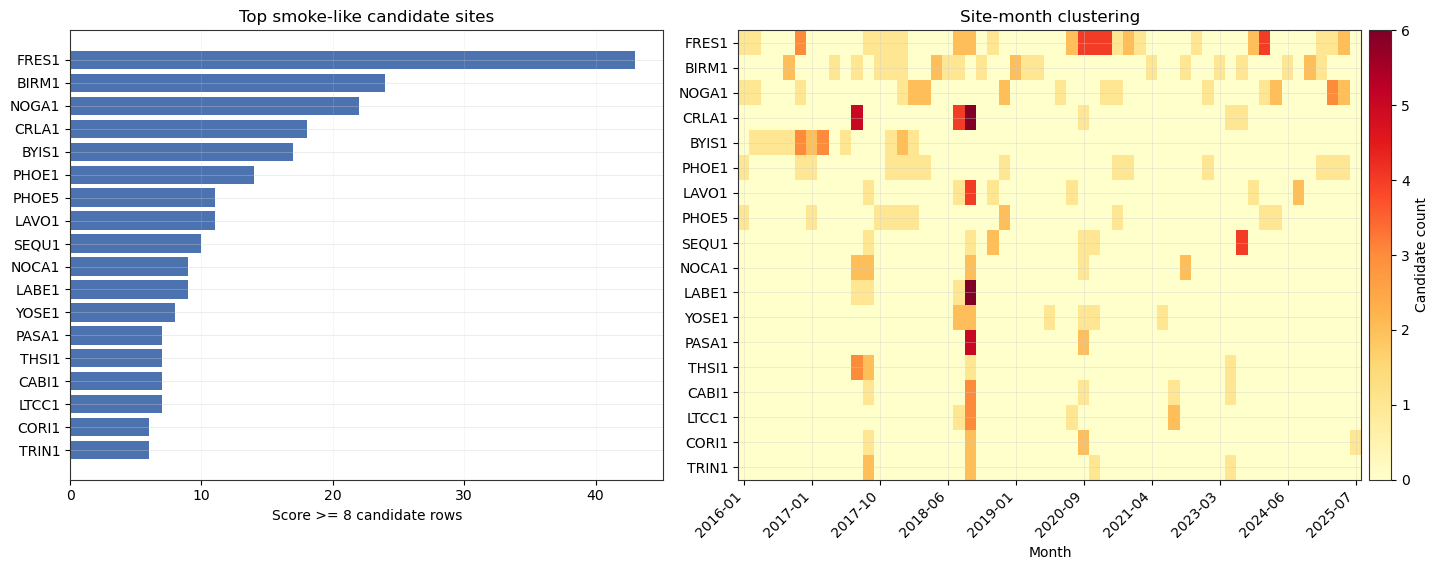

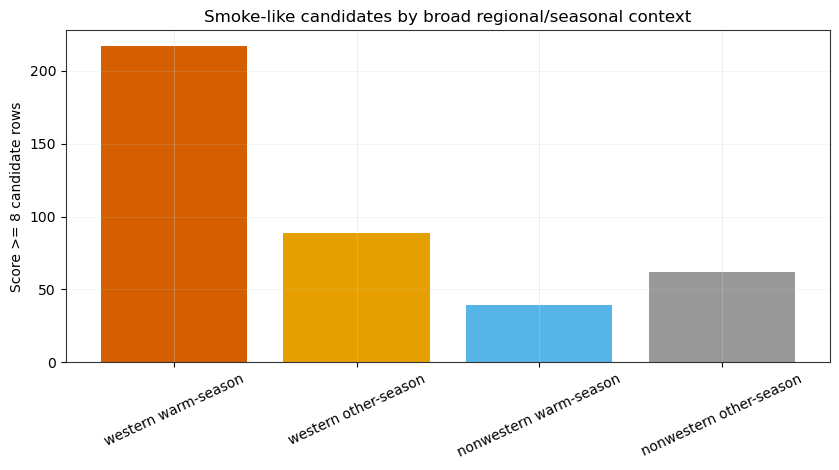

,SiteCode,SiteName,State,year_month,n_candidates
62,CRLA1,Crater Lake NP,OR,2018-08,6
129,LABE1,Lava Beds NM,CA,2018-08,6
60,CRLA1,Crater Lake NP,OR,2017-08,5
182,PASA1,Pasayten,WA,2018-08,5
61,CRLA1,Crater Lake NP,OR,2018-07,4
90,FRES1,Fresno,CA,2020-09,4
91,FRES1,Fresno,CA,2020-10,4
92,FRES1,Fresno,CA,2020-11,4
98,FRES1,Fresno,CA,2023-12,4
132,LAVO1,Lassen Volcanic NP,CA,2018-08,4


In [9]:
# Site-month clustering and regional context for score >= 8 candidates.
candidates = score_ge8.copy()
site_month_counts = (
    candidates
    .groupby(["SiteCode", "SiteName", "State", "year_month"], dropna=False)
    .size()
    .reset_index(name="n_candidates")
    .sort_values(["n_candidates", "SiteCode", "year_month"], ascending=[False, True, True])
)
site_month_counts.to_csv(OUT_DIR / "improve_site_month_candidate_counts.csv", index=False)

top_sites = candidates["SiteCode"].value_counts().head(18).index.tolist()
heat = (
    candidates[candidates["SiteCode"].isin(top_sites)]
    .pivot_table(index="SiteCode", columns="year_month", values="smoke_like_score", aggfunc="size", fill_value=0)
    .reindex(top_sites)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1.0, 1.25]})

ax = axes[0]
site_counts = candidates["SiteCode"].value_counts().head(18).sort_values()
ax.barh(site_counts.index, site_counts.values, color="#4C72B0")
ax.set_title("Top smoke-like candidate sites")
ax.set_xlabel("Score >= 8 candidate rows")
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
if heat.empty:
    ax.text(0.5, 0.5, "No score >= 8 candidates", ha="center", va="center")
    ax.axis("off")
else:
    im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)
    xticks = np.arange(0, len(heat.columns), max(1, len(heat.columns) // 8))
    ax.set_xticks(xticks)
    ax.set_xticklabels([heat.columns[i] for i in xticks], rotation=45, ha="right")
    ax.set_title("Site-month clustering")
    ax.set_xlabel("Month")
    fig.colorbar(im, ax=ax, pad=0.01, label="Candidate count")

fig.tight_layout()
fig.savefig(OUT_DIR / "improve_candidate_site_month_clustering.png", dpi=240, bbox_inches="tight")
plt.show()

context_counts = (
    candidates
    .groupby("event_context")
    .size()
    .reindex(["western warm-season", "western other-season", "nonwestern warm-season", "nonwestern other-season"])
    .fillna(0)
)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(context_counts.index, context_counts.values, color=["#D55E00", "#E69F00", "#56B4E9", "#999999"])
ax.set_title("Smoke-like candidates by broad regional/seasonal context")
ax.set_ylabel("Score >= 8 candidate rows")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "improve_candidate_regional_context.png", dpi=240, bbox_inches="tight")
plt.show()

display(site_month_counts.head(30))

## 7. RT Geometry Diagnostics

Treat zero or near-zero transmittance/reflectance ratios as saturation flags. The clipped `trans_od_proxy` is useful for ranking, but saturated rows should be analyzed as a separate class rather than interpreted as precise optical depth.

,group,n,sites,fAbs_median,fAbs_p95,EC_loading_median,OC_EC_median
0,RT saturated,1615,139,5.16,19.472,5.3973,6.4781
1,RT not saturated,143585,167,1.28,5.370,0.9075,5.6292


,SiteCode,SiteName,State,Date,POC,AuxID,ECf_Val,OCf_Val,fAbs_Val,EC_loading_ug_cm2_area_3p5,OC_EC,MF_Val,trans_min_over_initial,trans_od_proxy,rt_saturated,western_us,warm_season
370842,NOGA1,Nogales,AZ,2024-01-01,1,0,6.88931,50.74167,310.95,20.259609,7.365276,322.52312,0.000000,20.723266,True,True,False
281895,LAVO1,Lassen Volcanic NP,CA,2023-11-02,1,0,9.27957,428.14918,184.22,29.915339,46.138903,794.98347,0.000000,20.723266,True,True,False
281984,LAVO1,Lassen Volcanic NP,CA,2024-07-26,1,0,7.17680,43.64804,74.89,33.618434,6.081825,156.89988,0.000000,20.723266,True,True,True
612167,WIMO1,Wichita Mountains,OK,2024-10-27,1,0,2.63763,39.16758,71.38,11.859180,14.849535,244.88371,0.000000,20.723266,True,False,True
399494,PHOE1,Phoenix,AZ,2021-01-01,1,0,3.45283,28.94404,63.45,24.768037,8.382701,144.50292,0.000000,20.723266,True,True,False
370109,NOGA1,Nogales,AZ,2017-12-24,1,0,12.74510,24.83370,62.93,104.388924,1.948490,79.05788,0.000000,20.723266,True,True,False
171868,FRES1,Fresno,CA,2025-01-01,1,0,3.95789,10.04115,59.85,21.227760,2.536996,64.29440,0.000000,20.723266,True,True,False
562566,TRIN1,Trinity,CA,2017-09-04,1,0,4.47185,88.93250,59.34,32.395104,19.887183,164.00748,0.000000,20.723266,True,True,True
370956,NOGA1,Nogales,AZ,2024-12-08,1,0,3.07837,5.54130,54.47,21.281323,1.800076,38.88178,0.000000,20.723266,True,True,False
66600,BRIG1,Brigantine NWR,NJ,2023-06-08,1,0,19.83952,35.30347,45.64,86.674264,1.779452,189.91043,0.000000,20.723266,True,False,True


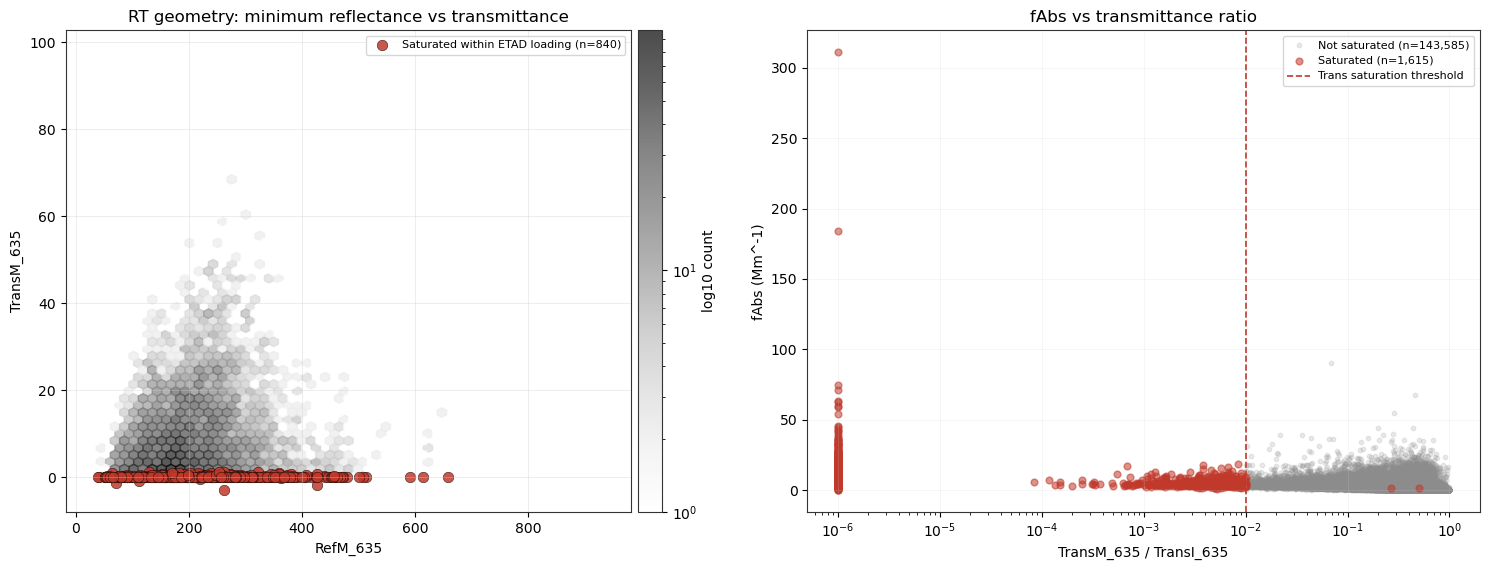

In [10]:
saturation_candidates = qc[qc["rt_saturated"]].sort_values(
    ["fAbs_Val", "EC_loading_ug_cm2_area_3p5"], ascending=[False, False]
).copy()
saturation_candidates.to_csv(OUT_DIR / "improve_saturation_candidates.csv", index=False)

sat_summary = pd.DataFrame([
    {
        "group": "RT saturated",
        "n": len(saturation_candidates),
        "sites": saturation_candidates["SiteCode"].nunique(),
        "fAbs_median": saturation_candidates["fAbs_Val"].median(),
        "fAbs_p95": saturation_candidates["fAbs_Val"].quantile(0.95),
        "EC_loading_median": saturation_candidates["EC_loading_ug_cm2_area_3p5"].median(),
        "OC_EC_median": saturation_candidates["OC_EC"].median(),
    },
    {
        "group": "RT not saturated",
        "n": int((~qc["rt_saturated"]).sum()),
        "sites": qc.loc[~qc["rt_saturated"], "SiteCode"].nunique(),
        "fAbs_median": qc.loc[~qc["rt_saturated"], "fAbs_Val"].median(),
        "fAbs_p95": qc.loc[~qc["rt_saturated"], "fAbs_Val"].quantile(0.95),
        "EC_loading_median": qc.loc[~qc["rt_saturated"], "EC_loading_ug_cm2_area_3p5"].median(),
        "OC_EC_median": qc.loc[~qc["rt_saturated"], "OC_EC"].median(),
    },
])
display(sat_summary.round(4))
saturation_display_cols = [c for c in candidate_cols if c in saturation_candidates.columns]
display(saturation_candidates[saturation_display_cols].head(25))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
bg = loading_matched.dropna(subset=["RefM_635_Val", "TransM_635_Val"])
hb = ax.hexbin(
    bg["RefM_635_Val"],
    bg["TransM_635_Val"],
    gridsize=55,
    mincnt=1,
    bins="log",
    cmap="Greys",
    alpha=0.7,
)
fig.colorbar(hb, ax=ax, pad=0.01, label="log10 count")
sat_lm = loading_matched[loading_matched["rt_saturated"]]
ax.scatter(
    sat_lm["RefM_635_Val"],
    sat_lm["TransM_635_Val"],
    s=58,
    color="#C0392B",
    edgecolor="black",
    linewidth=0.35,
    alpha=0.85,
    label=f"Saturated within ETAD loading (n={len(sat_lm):,})",
)
ax.set_xlabel("RefM_635")
ax.set_ylabel("TransM_635")
ax.set_title("RT geometry: minimum reflectance vs transmittance")
ax.legend(fontsize=8)

ax = axes[1]
nonsat = qc[~qc["rt_saturated"]].dropna(subset=["trans_min_over_initial", "fAbs_Val"])
sat = qc[qc["rt_saturated"]].dropna(subset=["trans_min_over_initial", "fAbs_Val"])
ax.scatter(
    nonsat["trans_min_over_initial"],
    nonsat["fAbs_Val"],
    s=10,
    color="0.55",
    alpha=0.18,
    label=f"Not saturated (n={len(nonsat):,})",
)
ax.scatter(
    sat["trans_min_over_initial"].clip(lower=1e-6),
    sat["fAbs_Val"],
    s=24,
    color="#C0392B",
    alpha=0.55,
    label=f"Saturated (n={len(sat):,})",
)
ax.axvline(TRANS_SATURATION_RATIO, color="#C0392B", ls="--", lw=1.2, label="Trans saturation threshold")
ax.set_xscale("log")
ax.set_xlabel("TransM_635 / TransI_635")
ax.set_ylabel("fAbs (Mm^-1)")
ax.set_title("fAbs vs transmittance ratio")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUT_DIR / "improve_rt_geometry_diagnostics.png", dpi=240, bbox_inches="tight")
plt.show()

## 8. Regression Sensitivity

Compare OLS, origin-through-zero MAC, and a sampled Theil-Sen robust fit across the main analysis groups.

,group,site_count,n,slope,intercept,r2,origin_mac,theilsen_slope,theilsen_intercept,theilsen_n,fAbs_median,EC_median,rt_saturated_pct
0,all_valid_improve,214,379697,5.3674,1.1418,0.5673,6.7041,10.2474,0.2548,5000,1.5102,0.1213,0.4327
1,rt_plus_loading_available,167,145200,3.5592,1.2990,0.3950,4.5949,10.1954,0.2194,5000,1.3000,0.1057,1.1123
2,etad_loading_matched,158,6946,6.9176,1.6935,0.5083,8.4499,6.3074,2.1760,5000,7.1000,0.7799,12.0933
3,etad_loading_and_fabs,14,24,5.4038,24.0904,0.1339,16.2789,3.6369,25.6025,24,33.0200,2.0395,25.0000
4,smoke_like_score_ge8,85,407,0.6493,19.0213,0.0280,2.4663,1.4662,14.1094,407,17.4100,2.2511,47.4201
5,rt_saturated,139,1615,1.7283,5.7926,0.1481,2.6086,5.8464,1.5346,1615,5.1600,0.6201,100.0000
6,rt_not_saturated,167,143585,4.3983,1.1248,0.5025,5.6984,10.1860,0.2254,5000,1.2800,0.1043,0.0000


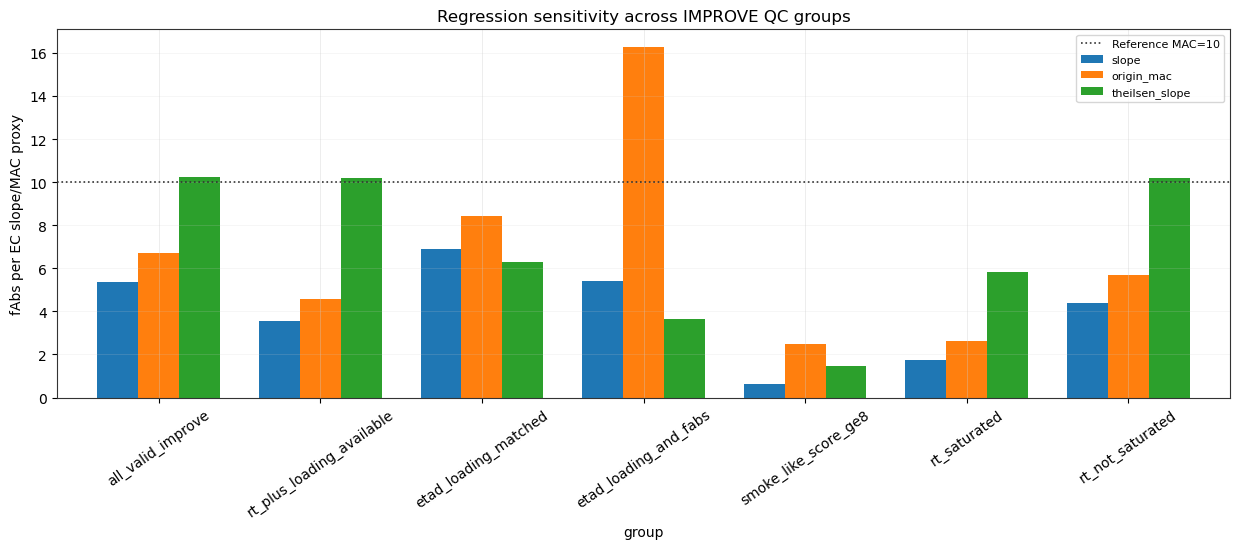

In [11]:
def regression_stats(df, x_col="ECf_Val", y_col="fAbs_Val"):
    pair = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    pair = pair[(pair[x_col] > 0) & (pair[y_col] > 0)]
    if len(pair) < 3 or pair[x_col].nunique() < 2:
        return {
            "n": len(pair),
            "slope": np.nan,
            "intercept": np.nan,
            "r2": np.nan,
            "origin_mac": np.nan,
            "theilsen_slope": np.nan,
            "theilsen_intercept": np.nan,
            "theilsen_n": len(pair),
        }
    x = pair[x_col].to_numpy(float)
    y = pair[y_col].to_numpy(float)
    slope, intercept, r, p, se = stats.linregress(x, y)
    origin_mac = np.dot(x, y) / np.dot(x, x)

    ts_pair = pair
    if len(ts_pair) > 5000:
        ts_pair = ts_pair.sample(n=5000, random_state=RANDOM_SEED)
    try:
        ts = stats.theilslopes(ts_pair[y_col].to_numpy(float), ts_pair[x_col].to_numpy(float))
        theilsen_slope = ts.slope
        theilsen_intercept = ts.intercept
    except Exception:
        theilsen_slope = np.nan
        theilsen_intercept = np.nan

    return {
        "n": len(pair),
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "origin_mac": origin_mac,
        "theilsen_slope": theilsen_slope,
        "theilsen_intercept": theilsen_intercept,
        "theilsen_n": len(ts_pair),
    }


regression_groups = {
    "all_valid_improve": valid_positive,
    "rt_plus_loading_available": qc,
    "etad_loading_matched": loading_matched,
    "etad_loading_and_fabs": both_matched,
    "smoke_like_score_ge8": score_ge8,
    "rt_saturated": qc[qc["rt_saturated"]],
    "rt_not_saturated": qc[~qc["rt_saturated"]],
}

fit_rows = []
for name, g in regression_groups.items():
    row = {"group": name, "site_count": g["SiteCode"].nunique() if len(g) else 0}
    row.update(regression_stats(g))
    row["fAbs_median"] = g["fAbs_Val"].median() if len(g) else np.nan
    row["EC_median"] = g["ECf_Val"].median() if len(g) else np.nan
    row["rt_saturated_pct"] = g["rt_saturated"].mean() * 100 if "rt_saturated" in g and len(g) else np.nan
    fit_rows.append(row)

fit_summary = pd.DataFrame(fit_rows)
fit_summary.to_csv(OUT_DIR / "improve_regression_sensitivity.csv", index=False)
display(fit_summary.round(4))

plot_fit = fit_summary.set_index("group")[["slope", "origin_mac", "theilsen_slope"]]
fig, ax = plt.subplots(figsize=(12.5, 5.6))
plot_fit.plot(kind="bar", ax=ax, width=0.76)
ax.axhline(MAC_VALUE, color="0.20", lw=1.2, ls=":", label=f"Reference MAC={MAC_VALUE:g}")
ax.set_title("Regression sensitivity across IMPROVE QC groups")
ax.set_ylabel("fAbs per EC slope/MAC proxy")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "improve_regression_sensitivity.png", dpi=240, bbox_inches="tight")
plt.show()

## 9. Exports and Readout

This final cell lists the main notebook artifacts and prints a short readout for meeting notes.

In [12]:
export_paths = [
    OUT_DIR / "improve_joined_qc.csv",
    OUT_DIR / "improve_smoke_event_candidates.csv",
    OUT_DIR / "improve_saturation_candidates.csv",
    OUT_DIR / "improve_site_month_candidate_counts.csv",
    OUT_DIR / "improve_etad_comparability_summary.csv",
    OUT_DIR / "improve_regression_sensitivity.csv",
    OUT_DIR / "improve_data_coverage_by_year.png",
    OUT_DIR / "improve_etad_comparable_fabs_vs_ec.png",
    OUT_DIR / "improve_candidate_site_month_clustering.png",
    OUT_DIR / "improve_candidate_regional_context.png",
    OUT_DIR / "improve_rt_geometry_diagnostics.png",
    OUT_DIR / "improve_regression_sensitivity.png",
]
exports = pd.DataFrame([
    {"path": str(path), "exists": path.exists(), "size_mb": path.stat().st_size / 1_000_000 if path.exists() else np.nan}
    for path in export_paths
])
display(exports)

print("Readout")
print(f"- Valid positive EC/fAbs rows: {len(valid_positive):,}")
print(f"- RT + loading rows: {len(qc):,}")
print(f"- ETAD-loading-matched rows: {len(loading_matched):,}")
print(f"- ETAD fAbs + loading rows: {len(both_matched):,}")
print(f"- p99 + ETAD-low loading + OC/EC >= 5 candidates: {len(p99_loading_ocec):,}")
print(f"- smoke_like_score >= 8 candidates: {len(score_ge8):,}")
print(f"- smoke_like_score >= 9 candidates: {len(score_ge9):,}")
print(f"- RT saturated rows in QC set: {int(qc['rt_saturated'].sum()):,}")
print("")
print("Interpretation prompt:")
print("Use the candidate tables and RT-saturation split to separate true smoke/event analogs from optical-regime artifacts before using IMPROVE as an Addis analog.")

,path,exists,size_mb
0,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_joined_qc.csv,True,205.350753
1,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_smoke_event_candidates.csv,True,0.071731
2,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_saturation_candidates.csv,True,0.828143
3,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_site_month_candidate_counts.csv,True,0.009764
4,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_etad_comparability_summary.csv,True,0.000661
5,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_regression_sensitivity.csv,True,0.001349
6,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_data_coverage_by_year.png,True,0.129649
7,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_etad_comparable_fabs_vs_ec.png,True,0.333751
8,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_candidate_site_month_clustering.png,True,0.189363
9,/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_smoke_event_qc/improve_candidate_regional_context.png,True,0.117544


Readout
- Valid positive EC/fAbs rows: 379,697
- RT + loading rows: 145,200
- ETAD-loading-matched rows: 6,946
- ETAD fAbs + loading rows: 24
- p99 + ETAD-low loading + OC/EC >= 5 candidates: 335
- smoke_like_score >= 8 candidates: 407
- smoke_like_score >= 9 candidates: 144
- RT saturated rows in QC set: 1,615

Interpretation prompt:
Use the candidate tables and RT-saturation split to separate true smoke/event analogs from optical-regime artifacts before using IMPROVE as an Addis analog.
